In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pickle

sys.path.append('.')
from trajectory import World
from toroidal_coordinates.dreimac_toroidal import compute_toroidal_coords_dreimac
from toroidal_coordinates.toroidal_lifting import toroidal_lifting_distance
from toroidal_coordinates.compute_coord import visualize_tor_coords_x_traj, interp_arr
from constants import GRID_FIELDS_PATH, TRAJ_PATH

In [ ]:
num_holes = 2
grid_path = os.path.join(GRID_FIELDS_PATH, f"world_{num_holes}holes")
traj_path = os.path.join(TRAJ_PATH, f"random_walk_{num_holes}holes.pkl")

In [3]:
traj = pickle.load(open(traj_path, "rb"))[0]
    
grid_rates = pickle.load(open(os.path.join(grid_path, "simulation_result.pkl"), "rb")).T

with np.load(os.path.join(grid_path, "toroidal_coords_dreimac.npz")) as data:
    tor_coords = data["coords"]
    
# Decrease the sampling rate
decrease_factor = 100
grid_rates = grid_rates[::decrease_factor]
tor_coords = tor_coords[::decrease_factor]

1.5477432483900213


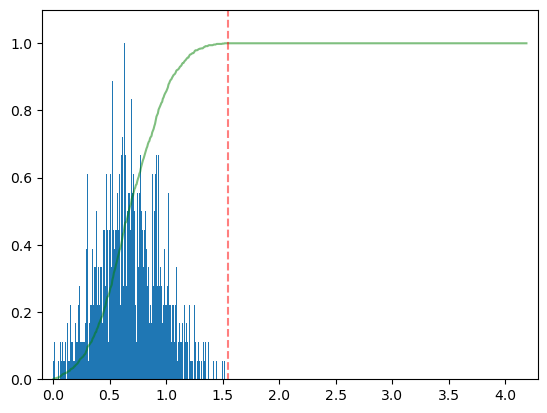

In [4]:
lifted_path = toroidal_lifting_distance(tor_coords)
    
traj_x = interp_arr(traj[:, 0], lifted_path.shape[0])
traj_y = interp_arr(traj[:, 1], lifted_path.shape[0])

(6000, 2)


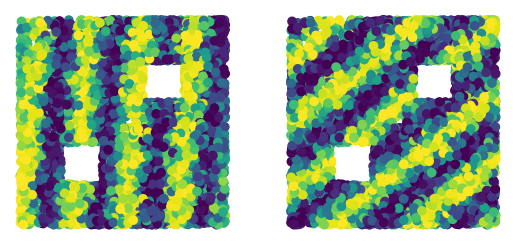

In [5]:
visualize_tor_coords_x_traj(traj_x, traj_y, lifted_path, np.arange(lifted_path.shape[0]))

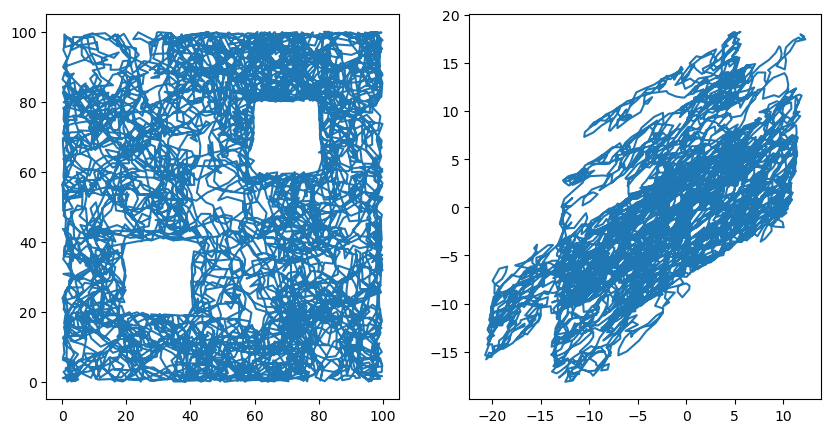

In [6]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(traj_x, traj_y)
plt.subplot(1, 2, 2)
plt.plot(lifted_path[:, 0], lifted_path[:, 1])

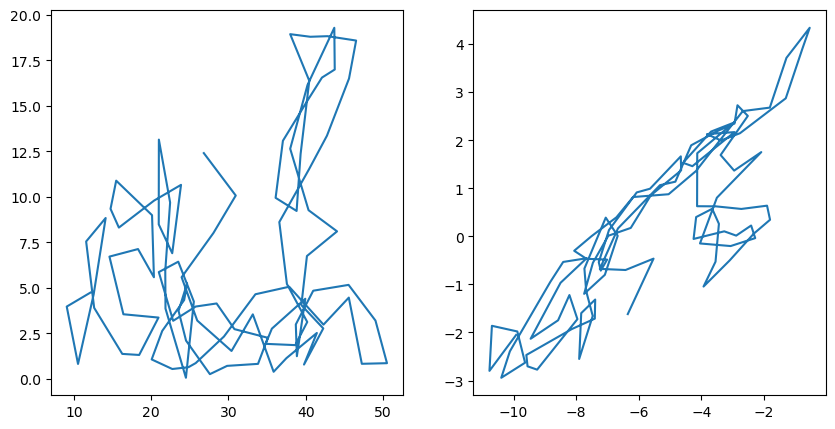

In [7]:
start = 500
end = start + 100
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(traj_x[start:end], traj_y[start:end])
plt.subplot(1, 2, 2)
plt.plot(lifted_path[start:end, 0], lifted_path[start:end, 1])